# Install & Import Libraries

In [1]:
!pip install -q transformers datasets accelerate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import torch
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict, Features, Sequence, Value
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import collections

# Load Dataset & Build Fixed-Length Sequences
Membaca dataset TSV, membuang baris pertama, membuat potongan sequence ukuran 128 token.

In [4]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/nlp/SINGGALANG_oversampled.tsv"

df = pd.read_csv(
    path,
    sep="\t",
    header=None,
    skiprows=[0],        # membuang baris pertama ("0 1")
    names=["token", "label"],
    dtype=str
)

MAX_LEN = 128
tokens = df["token"].tolist()
labels = df["label"].tolist()

sentences = []
sentence_labels = []

for i in range(0, len(tokens), MAX_LEN):
    sentences.append(tokens[i:i+MAX_LEN])
    sentence_labels.append(labels[i:i+MAX_LEN])

print("Total rows:", len(df))
print("Total sequences:", len(sentences))


Mounted at /content/drive
Total rows: 5360092
Total sequences: 41876


# Label Mapping & Convert to IDs
Membuat daftar label dan mengubah label string menjadi ID numerik.

In [5]:
label_list = sorted(df["label"].unique())
label_to_id = {l: i for i, l in enumerate(label_list)}
id_to_label = {i: l for l, i in label_to_id.items()}

label_ids = [[label_to_id[l] for l in seq] for seq in sentence_labels]

print("Labels:", label_list)
print("Mapping:", label_to_id)


Labels: ['O', 'Organisation', 'Person', 'Place']
Mapping: {'O': 0, 'Organisation': 1, 'Person': 2, 'Place': 3}


# Train/Validation Split & Build HF Dataset
Memecah data menjadi train 80% dan validation 20% secara acak agar distribusi label seimbang.

In [6]:
indices = list(range(len(sentences)))

train_idx, val_idx = train_test_split(
    indices, test_size=0.2, shuffle=True, random_state=42
)

train_data = {
    "tokens": [[str(tok) for tok in sentences[i]] for i in train_idx],
    "ner_tags": [[int(x) for x in label_ids[i]] for i in train_idx],
}

val_data = {
    "tokens": [[str(tok) for tok in sentences[i]] for i in val_idx],
    "ner_tags": [[int(x) for x in label_ids[i]] for i in val_idx],
}

features = Features({
    "tokens": Sequence(Value("string")),
    "ner_tags": Sequence(Value("int64"))
})

train_dataset = Dataset.from_dict(train_data, features=features)
val_dataset   = Dataset.from_dict(val_data, features=features)

dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset
})

print(dataset_dict)


DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 33500
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 8376
    })
})


# Load Tokenizer & Tokenize with Label Alignment
Tokenisasi sequence dan menyelaraskan label ke tiap sub-word.

In [7]:
model_name = "ChristopherA08/IndoELECTRA"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(batch):
    tokenized = tokenizer(
        batch["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding=False
    )

    aligned_labels = []

    for i, labels in enumerate(batch["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous = None
        label_ids_seq = []

        for w in word_ids:
            if w is None:
                label_ids_seq.append(-100)
            elif w != previous:
                label_ids_seq.append(labels[w])
            else:
                label_ids_seq.append(-100)
            previous = w

        aligned_labels.append(label_ids_seq)

    tokenized["labels"] = aligned_labels
    return tokenized

tokenized_datasets = dataset_dict.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=["tokens", "ner_tags"]
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/33500 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/8376 [00:00<?, ? examples/s]

# Load Model, Resize Vocab, Freeze Backbone
Menyesuaikan vocab tokenizer ke model dan membekukan backbone agar hanya classifier dilatih.


In [8]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    label2id=label_to_id,
    id2label=id_to_label,
    ignore_mismatched_sizes=True
)

model.resize_token_embeddings(len(tokenizer))

for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total = trainable + frozen

print("Total parameters:", total)
print("Trainable parameters:", trainable)
print("Frozen parameters:", frozen)


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of ElectraForTokenClassification were not initialized from the model checkpoint at ChristopherA08/IndoELECTRA and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Total parameters: 112333828
Trainable parameters: 3076
Frozen parameters: 112330752


# Data Collator & Metrics
Collator untuk padding dan fungsi evaluasi SeqEval.

In [9]:
data_collator = DataCollatorForTokenClassification(tokenizer)

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=2)

    true_preds = [
        [id_to_label[p] for p, l in zip(pred_seq, label_seq) if l != -100]
        for pred_seq, label_seq in zip(preds, labels)
    ]

    true_labels = [
        [id_to_label[l] for p, l in zip(pred_seq, label_seq) if l != -100]
        for pred_seq, label_seq in zip(preds, labels)
    ]

    return {
        "f1": f1_score(true_labels, true_preds),
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds)
    }


# TrainingArguments & Trainer
Konfigurasi training

In [11]:
training_args = TrainingArguments(
    output_dir="./NER-IndoELECTRA",
    eval_strategy="epoch",
    save_strategy="epoch",
    optim="adamw_torch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    fp16=True,
    learning_rate=5e-4,
    weight_decay=0.01,
    logging_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


/tmp/ipython-input-363556014.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


# Training

In [12]:
trainer.train()

metrics = trainer.evaluate()
print(metrics)


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.203400,0.082898,0.450260,0.539431,0.386389
2,0.089500,0.071012,0.507345,0.559816,0.463868
3,0.081700,0.068730,0.514513,0.566677,0.471142


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Place seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Person seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Organisation seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Place seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Person seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_l

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Place seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Person seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Organisation seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


{'eval_loss': 0.06873045116662979, 'eval_f1': 0.5145126941207437, 'eval_precision': 0.5666772085178158, 'eval_recall': 0.4711424689951356, 'eval_runtime': 57.0165, 'eval_samples_per_second': 146.905, 'eval_steps_per_second': 4.595, 'epoch': 3.0}


# Kurva

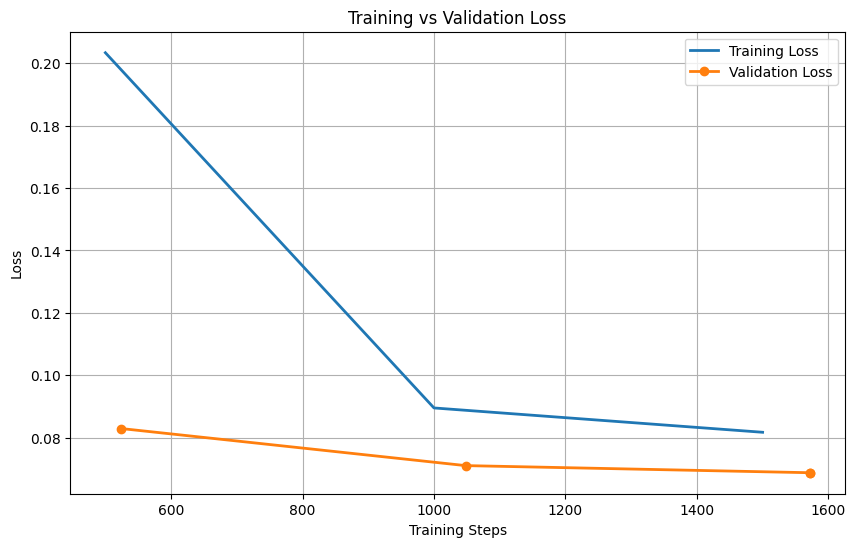

In [17]:
log_history = trainer.state.log_history

train_steps = []
train_loss = []
eval_steps = []
eval_loss = []

for entry in log_history:
    # training loss dicatat sebagai {"loss": ..., "step": ...}
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])

    # validation loss dicatat sebagai {"eval_loss": ..., "step": ...}
    if "eval_loss" in entry and "step" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

plt.figure(figsize=(10,6))

# Plot training loss
plt.plot(train_steps, train_loss, label="Training Loss", linewidth=2)

# Plot validation loss
plt.plot(eval_steps, eval_loss, label="Validation Loss", linewidth=2, marker='o')

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Classification Report
Menghitung precision/recall/F1 per label.

In [13]:
predictions, true_labels, _ = trainer.predict(tokenized_datasets["validation"])
pred_ids = np.argmax(predictions, axis=2)

true_tags = []
pred_tags = []

for true_seq, pred_seq in zip(true_labels, pred_ids):
    t, p = [], []
    for tl, pl in zip(true_seq, pred_seq):
        if tl != -100:
            t.append(id_to_label[tl])
            p.append(id_to_label[pl])
    true_tags.append(t)
    pred_tags.append(p)

print(classification_report(true_tags, pred_tags))


              precision    recall  f1-score   support

       erson       0.54      0.41      0.46      7656
        lace       0.58      0.50      0.54     15163

   micro avg       0.57      0.47      0.51     22819
   macro avg       0.56      0.46      0.50     22819
weighted avg       0.57      0.47      0.51     22819



# Confusion Matrix

TRUE counts: Counter({'O': 274235, 'Place': 271797, 'Organisation': 267705, 'Person': 258391})
PRED counts: Counter({'O': 285197, 'Place': 267006, 'Organisation': 264958, 'Person': 254967})
Labels used in confusion matrix: ['O', 'Organisation', 'Person', 'Place']


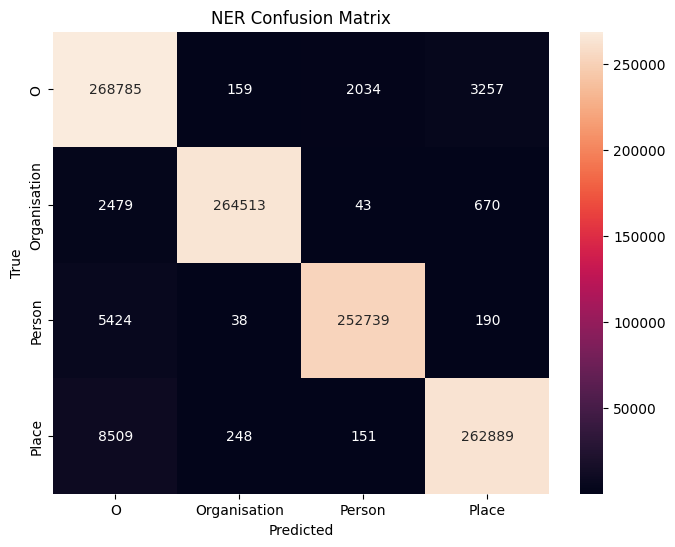

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import collections

# Flatten true and pred tags
flat_true = [tag for seq in true_tags for tag in seq]
flat_pred = [tag for seq in pred_tags for tag in seq]

print("TRUE counts:", collections.Counter(flat_true))
print("PRED counts:", collections.Counter(flat_pred))

labels_in_true = set(flat_true)
labels_in_pred = set(flat_pred)

valid_labels = sorted(list(labels_in_true.union(labels_in_pred)))

print("Labels used in confusion matrix:", valid_labels)

# Hitung confusion matrix
cm = confusion_matrix(flat_true, flat_pred, labels=valid_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=valid_labels,
            yticklabels=valid_labels)

plt.title("NER Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
